# Apical image quality estimation

Here we use a [Mobilenet based network](https://www.sciencedirect.com/science/article/pii/S0301562924004691) to get the regional image quality for apical views.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/models/apical_image_quality_example.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/models/apical_image_quality_example.ipynb)
&nbsp;
[![Hugging Face model](https://img.shields.io/badge/Hugging%20Face-Model-yellow?logo=huggingface)](https://huggingface.co/gillesvdv/mobilenetv2_regional_quality)
&nbsp;
[![UMB](https://img.shields.io/badge/UMB-Paper-431E4F.svg)](https://www.sciencedirect.com/science/article/pii/S0301562924004691)

In [1]:
%%capture
%pip install zea

In [2]:
import os

# NOTE: should be `tensorflow` or `jax` for EchoNetDynamic
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import matplotlib.pyplot as plt
from keras import ops

from zea import init_device, log
from zea.backend.tensorflow.dataloader import make_dataloader
from zea.tools.selection_tool import add_shape_from_mask
from zea.utils import translate
from zea.visualize import plot_image_grid, set_mpl_style

init_device(verbose=False)
set_mpl_style()

zea: Using backend 'tensorflow'


/home/gillesv/PycharmProjects/zea/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


zea: WARNING Failed to retrieve GPU memory: Command '['nvidia-smi', '--query-gpu=memory.free', '--format=csv,noheader,nounits']' returned non-zero exit status 9.


### Load image quality model

In [3]:
from zea.models.myocardial_img_quality import myocardial_img_quality
INFERENCE_SIZE = 256
model = myocardial_img_quality()
# load weights from huggingface
model.custom_load_weights()

Archive:  ./models--gillesvdv--mobilenetv2_regional_quality/snapshots/a41e68bfb978711d8f5d8ed71a965e62a4b923ed/mobilenetv2_regional_quality.zip
   creating: ./mobilenetv2_regional_quality/
  inflating: ./mobilenetv2_regional_quality/model.onnx  
  inflating: ./mobilenetv2_regional_quality/slope_intercept_bias_correction.npy  


Now let's load some data (for more info see the [zea_data_example](../data/zea_data_example.ipynb) notebook), and perform inference on the data to segment the left ventricle.

In [4]:
# Arqee contains a helper function for visualization of segmentation masks
!pip install git+https://github.com/GillesVanDeVyver/arqee

  Cloning https://github.com/GillesVanDeVyver/arqee to /tmp/pip-req-build-uxtniu56
  Running command git clone --filter=blob:none --quiet https://github.com/GillesVanDeVyver/arqee /tmp/pip-req-build-uxtniu56
  Resolved https://github.com/GillesVanDeVyver/arqee to commit cf8d40048ba89e02a93dd65e9006e2c22e02a7e5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [5]:
import numpy as np
import arqee

n_imgs = 1
val_dataset = make_dataloader(
    "hf://zeahub/camus-sample/val",
    key="data/image_sc",
    batch_size=n_imgs,
    shuffle=True,
    image_range=[-45, 0],
    clip_image_range=True,
    normalization_range=[-1, 1],
    image_size=(INFERENCE_SIZE, INFERENCE_SIZE),
    resize_type="resize",
    seed=42,
)

batch = next(iter(val_dataset))
batch_np = ops.convert_to_numpy(batch)
us_image = batch_np[0,:,:,0] # using just a single image for the example

# ONNX expects NCHW: (batch, channels, depth, width)
onnx_input = np.transpose(batch_np, (0, 3, 1, 2))

outputs = model.call(onnx_input)
outputs = np.array(outputs)

# seg model vor visualization
model_name_seg = 'nnunet_camus'
arqee.download_and_set_up_model(model_name_seg)
model_object_seg = arqee.load_model(model_name_seg)
segmentation = model_object_seg.predict_img(np.expand_dims(us_image, axis=0),verbose=False)


arqee.plot_quality_prediction_result(us_image,segmentation,outputs[0])

plt.savefig("myocardial_image_quality.png")
plt.close()


zea: Using pregenerated dataset info file: /home/gillesv/.cache/zea/huggingface/datasets/datasets--zeahub--camus-sample/snapshots/617cf91a1267b5ffbcfafe9bebf0813c7cee8493/val/dataset_info.yaml ...
zea: ...for reading file paths in /home/gillesv/.cache/zea/huggingface/datasets/datasets--zeahub--camus-sample/snapshots/617cf91a1267b5ffbcfafe9bebf0813c7cee8493/val
zea: Dataset was validated on September 18, 2025
zea: Remove /home/gillesv/.cache/zea/huggingface/datasets/datasets--zeahub--camus-sample/snapshots/617cf91a1267b5ffbcfafe9bebf0813c7cee8493/val/validated.flag if you want to redo validation.
zea: WARNING H5Generator: Not all files have the same shape. This can lead to issues when resizing images later....
zea: H5Generator: Shuffled data.
zea: H5Generator: Shuffled data.
Download link for model with backbone nnunet_camus is ('gillesvdv/nnunet_CAMUS_onnx', 'nnunet_camus.zip')
Model downloaded to /home/gillesv/PycharmProjects/zea/.venv/lib/python3.10/site-packages/arqee/models/models-

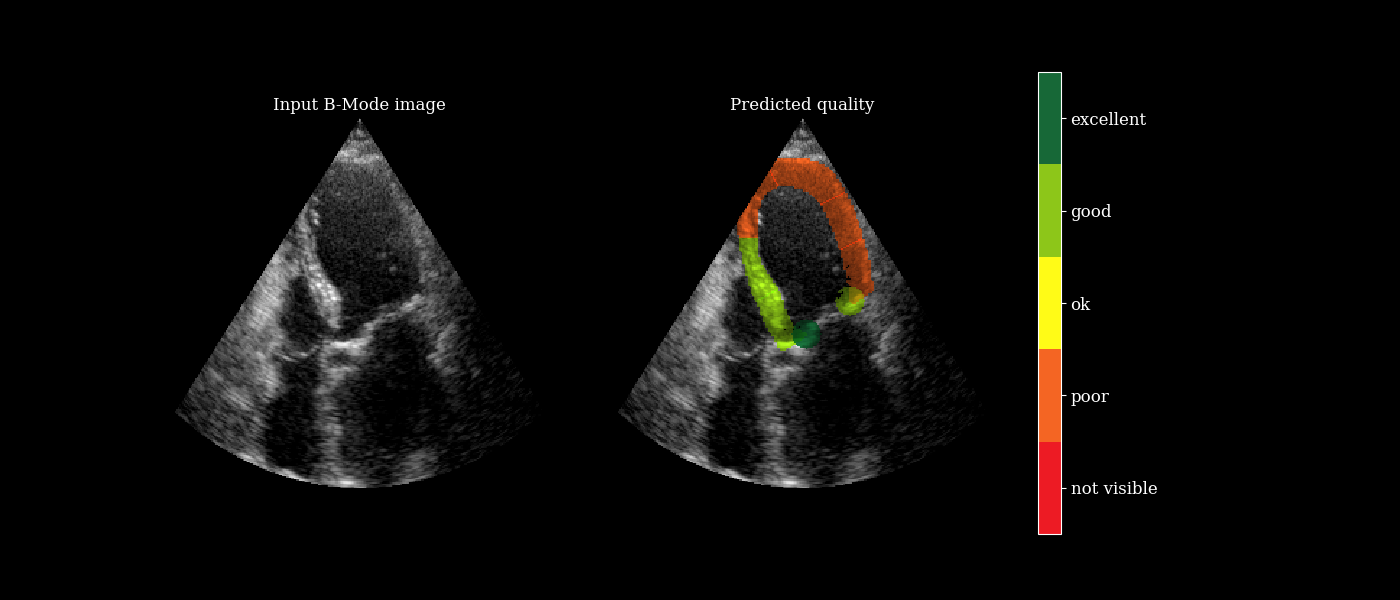